## Data Acquisition & Wrangling

In [8]:
import pandas as pd
import numpy as np

def monetary(file_path):
    df = pd.read_csv(file_path)

    # 1. Extract Years and Months to create a proper Date column
    years_row = df.columns.tolist()
    current_year = None
    years = []
    for col in years_row:
        if col.isdigit(): current_year = col
        years.append(current_year)
    
    months = df.iloc[1].tolist()
    
    # Create the date index (skipping the first 2 label columns)
    date_strings = [f"{y}-{m}" for y, m in zip(years[2:], months[2:]) if pd.notna(y) and pd.notna(m)]
    dates = pd.to_datetime(date_strings, format='%Y-%b', errors='coerce')

    # 2. Define the rows we want (Using exact labels from your CSV)
    target_indicators = {
        "Central Government (Net)": "Gov_Credit",
        "Private sector credit ": "Private_Credit",
        "Money and Quasi-money (M2)": "M2",
        "M2 plus Residents' Foreign Curr. Deposits (M3)": "M3"
    }

    cleaned_series = []
    labels_col = df.columns[1]

    for label, short_name in target_indicators.items():
        # Strip spaces and find the row
        mask = df[labels_col].str.strip() == label.strip()
        row_data = df[mask].iloc[0, 2:].values # Get values, skip first 2 cols
        
        # Clean commas and convert to float
        clean_vals = [float(str(x).replace(',', '').strip()) if pd.notna(x) else np.nan for x in row_data]
        cleaned_series.append(pd.Series(clean_vals[:len(dates)], name=short_name))

    # 3. Final DataFrame
    monetary_clean = pd.concat(cleaned_series, axis=1)
    monetary_clean.index = dates
    return monetary_clean.dropna(how='all').sort_index()

# Usage
monetary = monetary('D:\Asaph_Ray\DATA SCIENCE\DATA ANALYSIS\CBK MACROECONOMIC ANALYSIS\cbk-macroeconomic-analysis\data\cleaned\monetary.csv')
monetary.to_csv('monetary_cleaned.csv')
print("Successfully cleaned! Sample of the data:")
display(monetary.head())

Successfully cleaned! Sample of the data:


<>:47: SyntaxWarning: invalid escape sequence '\A'
<>:47: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9592\2933741715.py:47: SyntaxWarning: invalid escape sequence '\A'
  monetary = monetary('D:\Asaph_Ray\DATA SCIENCE\DATA ANALYSIS\CBK MACROECONOMIC ANALYSIS\cbk-macroeconomic-analysis\data\cleaned\monetary.csv')


,Gov_Credit,Private_Credit,M2,M3
2014-01-01,485582.0,1504518.0,1892935.0,2219443.0
2014-02-01,491059.0,1529663.0,1926275.0,2223692.0
2014-03-01,492119.0,1557527.0,1950769.0,2251459.0
2014-04-01,463151.0,1589945.0,1972126.0,2292530.0
2014-05-01,475320.0,1622702.0,2025073.0,2344653.0


## 1. Year-over-Year (YoY) Growth
The YoY growth rate removes "seasonal noise" (like typical December spending spikes) by comparing a month to the same month in the previous year.
$$\text{YoY Growth} = \left( \frac{\text{Value}_{t}}{\text{Value}_{t-12}} - 1 \right) \times 100$$

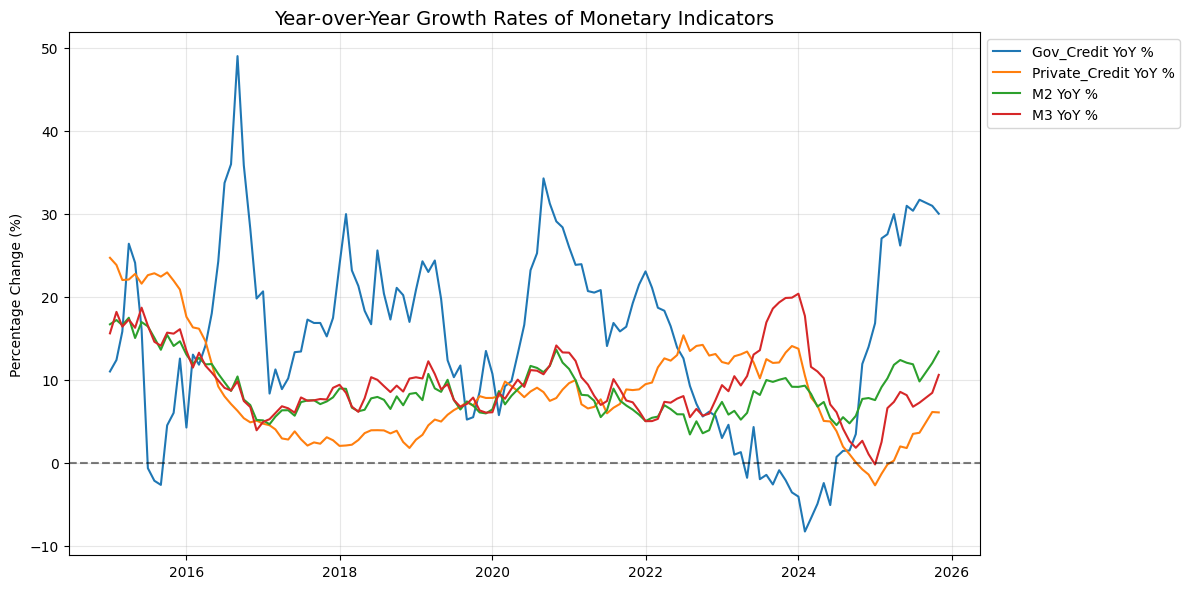

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculating YoY Growth
monetary_yoy = monetary.pct_change(periods=12) * 100

# 2. Visualize
plt.figure(figsize=(12, 6))
for col in monetary_yoy.columns:
    plt.plot(monetary_yoy.index, monetary_yoy[col], label=f'{col} YoY %')

plt.axhline(0, color='black', linestyle='--', alpha=0.5) # Baseline
plt.title('Year-over-Year Growth Rates of Monetary Indicators', fontsize=14)
plt.ylabel('Percentage Change (%)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Credit Composition (Private vs. Government)
This analysis identifies who is receiving the most credit in this economy. A high share of government credit relative to private credit can signal "Crowding Out," where government borrowing makes it harder or more expensive for businesses to get loans.

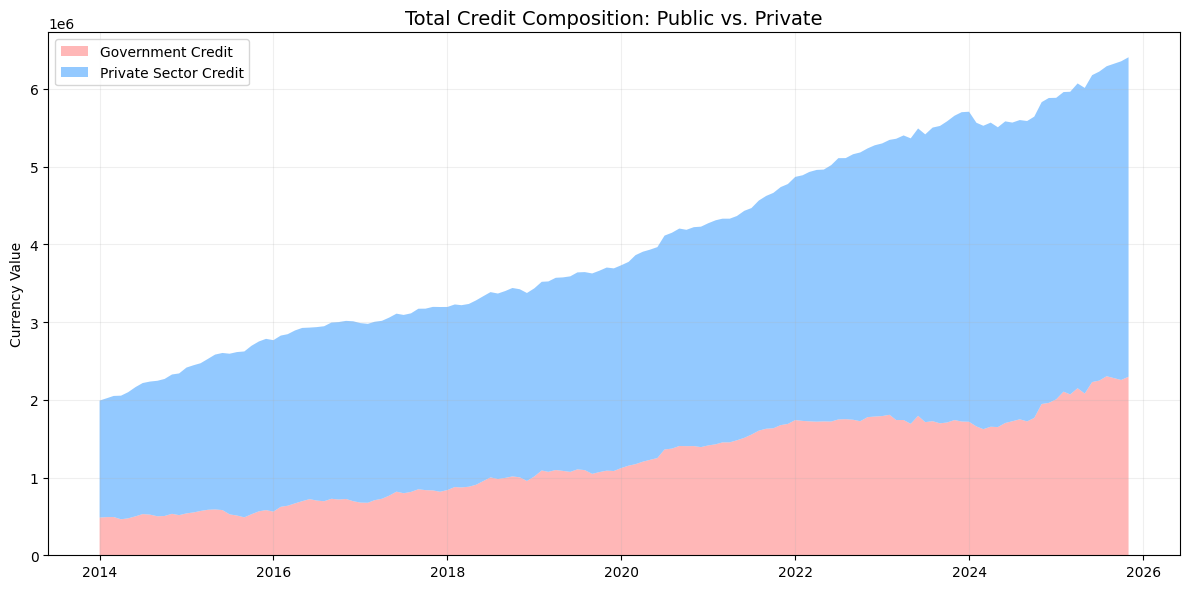

In [10]:
# 1. Calculating the Private Sector's share of total credit
total_credit = monetary['Private_Credit'] + monetary['Gov_Credit']
monetary['Private_Credit_Share'] = (monetary['Private_Credit'] / total_credit) * 100

# 2. Visualizing with a Stacked Area Chart
plt.figure(figsize=(12, 6))
plt.stackplot(monetary.index, 
              monetary['Gov_Credit'], 
              monetary['Private_Credit'], 
              labels=['Government Credit', 'Private Sector Credit'],
              alpha=0.7, colors=['#ff9999','#66b3ff'])

plt.title('Total Credit Composition: Public vs. Private', fontsize=14)
plt.ylabel('Currency Value')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 3. Money Aggregate Comparison ($M2$ vs $M3$)
Comparing $M2$ and $M3$ shows the "liquidity depth." If the gap between $M3$ and $M2$ is widening, it usually means residents are holding more foreign currency deposits or long-term savings.

In [ ]:
# 1. Let's calculate the spread/gap
monetary['M3_M2_Gap'] = monetary['M3'] - monetary['M2']

# 2. Visualize Levels and the Gap
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(monetary.index, monetary['M2'], label='M2 (Quasi-money)', color='blue', linewidth=2)
ax1.plot(monetary.index, monetary['M3'], label='M3 (Broad Money)', color='green', linestyle='--')
ax1.set_ylabel('Absolute Levels')
ax1.legend(loc='upper left')

# Create a second y-axis for the gap
ax2 = ax1.twinx()
ax2.fill_between(monetary.index, monetary['M3_M2_Gap'], color='gray', alpha=0.2, label='M3-M2 Gap')
ax2.set_ylabel('Gap Size (Foreign Deposits/Other)')

plt.title('M2 vs M3: Analyzing Liquidity Components', fontsize=14)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()